### 영상처리를 위한 딥러닝 - 5

In [1]:
import tensorflow as tf
import numpy as np

from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

In [2]:
# https://gruuuuu.github.io/machine-learning/cifar10-cnn/
(train_images,train_labels),(test_images,test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images,test_images = train_images / 255.,test_images /255.

### output layer  
- softmax : 실수값을 확률처럼 0~1 사이의 값으로 변경해주는 것이므로 없어도 가능
  - activation 차원 변형,공간 왜곡하는데 이에 따라 output layer 의 node갯수 상이
      - regression : 1개
      - binary classification :1개
        - sigmoid
      - classification: 클래스 갯수 n
        - softmax :사람이 이해하기 좋은 포맷으로 나옴(optional)

### softmax 문제점
- 아주 드문 경우지만 성능에 영향을 주는 경우가 있음 
- 확률값으로 바꾸면서 값들의 범위에 따라서 값이 일정 부분 잘려서 날라가는 경우(clipping)  
값이 다르게 나오는 경우가 생기게 되면서 numerical stability 문제 
- softmax 쓰면 사람이 이해하기 좋으나 overflow 문제로 성능 체크 
### logit
- numerical stability 문제 해결책  
      > - 통계: logistic regression 연관  
      > - DL 에서의 로지트(logit)  
        -  [머신러닝 용어집]  
        https://developers.google.com/machine-learning/glossary?hl=ko  
        :  분류 모델에서 생성되는 **원시(정규화되지 않음) 예측 벡터**로, 대개는 **정규화 함수**로 전달됩니다.  
        모델에서 다중 클래스 분류 문제를 해결하고 있는 경우 로지트는 **소프트맥스 함수의 입력**으로 사용되는 것이 일반적입니다. 그런 다음 소프트맥스 함수에서 가능한 클래스별로 하나의 값을 갖는 (정규화된) 확률 벡터를 생성합니다.     또한 로지트는 시그모이드 함수의 요소별 역을 지칭할 때도 있습니다. 자세한 내용은 tf.nn.sigmoid_cross_entropy_with_logits를 참조하세요.

In [ ]:
# 1) no softmax , from_logits=False 
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu', input_shape=(32, 32, 3)))

model.add(layers.Flatten())
model.add(layers.Dense(64,  activation='relu'))
model.add(layers.Dense(10))  # classification softmax 없음 -> 실수 범위

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

# CPU 약 7분 소요 / GPU RTX 3060 약 2분 소요 / Colab 약 1.3분 소요
model.fit(train_images, train_labels, epochs=10, 
                    validation_data=(test_images, test_labels))

Epoch 1/10
1563/1563 [==============================] - 15s 7ms/step - loss: 3.5134 - accuracy: 0.1501 - val_loss: 5.1655 - val_accuracy: 0.1000
Epoch 2/10
1563/1563 [==============================] - 11s 7ms/step - loss: 2.5865 - accuracy: 0.1190 - val_loss: 2.3026 - val_accuracy: 0.1000
Epoch 3/10
1563/1563 [==============================] - 10s 7ms/step - loss: 2.3025 - accuracy: 0.1000 - val_loss: 2.3026 - val_accuracy: 0.1000
Epoch 4/10
1563/1563 [==============================] - 10s 6ms/step - loss: 2.3026 - accuracy: 0.1000 - val_loss: 2.3026 - val_accuracy: 0.1000
Epoch 5/10
1563/1563 [==============================] - 11s 7ms/step - loss: 2.3026 - accuracy: 0.1000 - val_loss: 2.3026 - val_accuracy: 0.1000
Epoch 6/10
1563/1563 [==============================] - 10s 6ms/step - loss: 2.3026 - accuracy: 0.1000 - val_loss: 2.3026 - val_accuracy: 0.1000
Epoch 7/10
1563/1563 [==============================] - 9s 6ms/step - loss: 2.3026 - accuracy: 0.1000 - val_loss: 2.3026 - val_acc

[3]


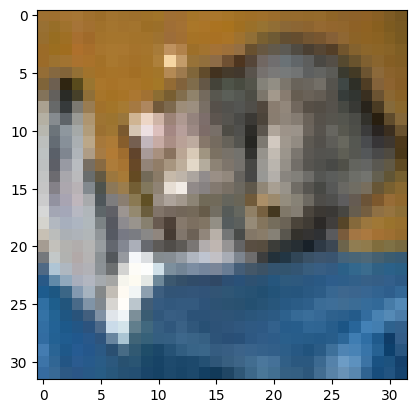

In [4]:
plt.imshow(test_images[0])
print(test_labels[0]) # 3, 고양이

In [5]:
print(test_images[0].shape)
print(test_images[0][tf.newaxis].shape)

(32, 32, 3)
(1, 32, 32, 3)


In [6]:
t = model.predict(test_images[0][tf.newaxis])
t

1/1 [==============================] - 0s 251ms/step


array([[17.277792 ,  8.422252 ,  6.9757423,  5.1057854,  5.968648 ,
         7.8365083,  7.029505 ,  5.3573165,  8.339183 ,  7.0719514]],
      dtype=float32)

In [7]:
np.sum(t)  # softmax 없으므로 합이 1이 아님

79.38468

In [8]:
np.argmax(t) # 3인데 완전히 다르게 예측

0

In [ ]:
# 2)  softmax , from_logits=False --> 흔히 쓰는 모델
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax') )

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

# CPU 약 6분 소요 / GPU RTX 3060 약 2분 소요 
model.fit(train_images, train_labels, epochs=10, 
                    validation_data=(test_images, test_labels))

Epoch 1/10
1563/1563 [==============================] - 12s 7ms/step - loss: 1.5340 - accuracy: 0.4391 - val_loss: 1.2710 - val_accuracy: 0.5361
Epoch 2/10
1563/1563 [==============================] - 9s 6ms/step - loss: 1.1692 - accuracy: 0.5869 - val_loss: 1.1408 - val_accuracy: 0.5991
Epoch 3/10
1563/1563 [==============================] - 10s 6ms/step - loss: 1.0230 - accuracy: 0.6375 - val_loss: 0.9959 - val_accuracy: 0.6491
Epoch 4/10
1563/1563 [==============================] - 11s 7ms/step - loss: 0.9291 - accuracy: 0.6738 - val_loss: 0.9931 - val_accuracy: 0.6540
Epoch 5/10
1563/1563 [==============================] - 10s 6ms/step - loss: 0.8529 - accuracy: 0.7003 - val_loss: 0.8919 - val_accuracy: 0.6909
Epoch 6/10
1563/1563 [==============================] - 10s 7ms/step - loss: 0.7979 - accuracy: 0.7176 - val_loss: 0.8832 - val_accuracy: 0.6993
Epoch 7/10
1563/1563 [==============================] - 14s 9ms/step - loss: 0.7493 - accuracy: 0.7359 - val_loss: 0.9030 - val_acc

In [10]:
t = model.predict(test_images[0][tf.newaxis])
t

1/1 [==============================] - 0s 84ms/step


array([[3.4825441e-03, 1.7417487e-04, 2.2547913e-03, 9.6564794e-01,
        1.2804052e-03, 2.2549288e-02, 1.9224057e-03, 9.6490039e-05,
        2.3054220e-03, 2.8665687e-04]], dtype=float32)

In [11]:
np.sum(t)  # softmax로 총 합 1

1.0000001

In [12]:
np.argmax(t)

3

## from_logits
- paramter에 객체방식으로 default 값 변경 가능
   - `SparseCategoricalCrossentropy(from_logits=False )` (기본값)
>	Whether y_pred is expected to be a logits tensor. **By default, we assume that y_pred encodes a probability distribution.**
 Note - Using from_logits=True may be more **numerically stable.**
  - 참고: https://www.tensorflow.org/api_docs/python/tf/keras/losses/SparseCategoricalCrossentropy

In [13]:
# 3) no softmax , from_logits=True --> 1)번 모델보다 더 안정적
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),  # softmax처럼 해줌 //총합은 1 아님
              metrics=['accuracy'])

# CPU 약 6분 소요 / GPU RTX 3060 약 2분 소요 
history=model.fit(train_images, train_labels, epochs=10, 
                    validation_data=(test_images, test_labels))

Epoch 1/10
1563/1563 [==============================] - 16s 10ms/step - loss: 1.5205 - accuracy: 0.4495 - val_loss: 1.2720 - val_accuracy: 0.5356
Epoch 2/10
1563/1563 [==============================] - 11s 7ms/step - loss: 1.1676 - accuracy: 0.5860 - val_loss: 1.1255 - val_accuracy: 0.5885
Epoch 3/10
1563/1563 [==============================] - 12s 8ms/step - loss: 1.0237 - accuracy: 0.6366 - val_loss: 0.9957 - val_accuracy: 0.6521
Epoch 4/10
1563/1563 [==============================] - 13s 9ms/step - loss: 0.9314 - accuracy: 0.6742 - val_loss: 0.9242 - val_accuracy: 0.6768
Epoch 5/10
1563/1563 [==============================] - 11s 7ms/step - loss: 0.8627 - accuracy: 0.6961 - val_loss: 0.9725 - val_accuracy: 0.6634
Epoch 6/10
1563/1563 [==============================] - 12s 8ms/step - loss: 0.8061 - accuracy: 0.7179 - val_loss: 0.8991 - val_accuracy: 0.6896
Epoch 7/10
1563/1563 [==============================] - 12s 8ms/step - loss: 0.7578 - accuracy: 0.7318 - val_loss: 0.8892 - val_a

313/313 - 1s - loss: 0.8816 - accuracy: 0.7019 - 1s/epoch - 3ms/step


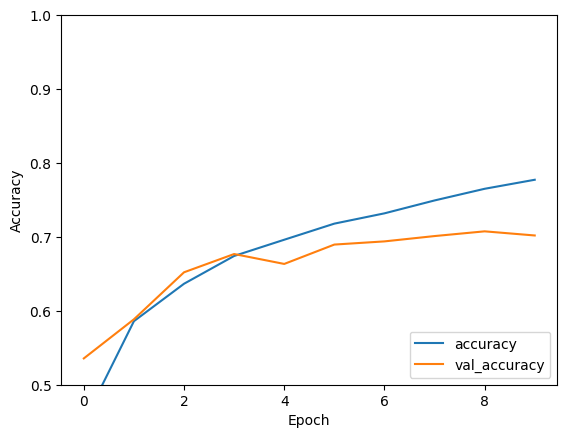

In [14]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

Learning Curve
- 모델 평가: 
    - 과적합 val accuracy < accuracy & 성능 0.8 미만  

In [15]:
t = model.predict(test_images[0][tf.newaxis])
t

1/1 [==============================] - 0s 70ms/step


array([[-1.2160040e+00, -3.7348592e+00, -7.2530329e-01,  4.6033258e+00,
        -7.9644364e-01,  3.6143260e+00,  1.5612370e+00, -5.0557777e-04,
        -1.9735824e+00, -3.1178050e+00]], dtype=float32)

In [16]:
np.sum(t) #  softmax처럼 해줌 그러나 총합은 1이 아님

-1.7856146

In [17]:
np.argmax(t) # 비슷하게 맞음

3

In [18]:
# 4) softmax, from_logits=True -> 훨씬 더 안정적
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax') )

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# CPU 약 6분 소요 / GPU RTX 3060 약 2분 소요 
model.fit(train_images, train_labels, epochs=10, 
                    validation_data=(test_images, test_labels))

Epoch 1/10


c:\MyCursorLab\tf210\.venv\lib\site-packages\keras\backend.py:5582: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1563/1563 [==============================] - 13s 8ms/step - loss: 1.5828 - accuracy: 0.4229 - val_loss: 1.2516 - val_accuracy: 0.5555
Epoch 2/10
1563/1563 [==============================] - 10s 6ms/step - loss: 1.1600 - accuracy: 0.5902 - val_loss: 1.0974 - val_accuracy: 0.6167
Epoch 3/10
1563/1563 [==============================] - 10s 7ms/step - loss: 1.0034 - accuracy: 0.6463 - val_loss: 1.0081 - val_accuracy: 0.6494
Epoch 4/10
1563/1563 [==============================] - 11s 7ms/step - loss: 0.9089 - accuracy: 0.6796 - val_loss: 0.9310 - val_accuracy: 0.6818
Epoch 5/10
1563/1563 [==============================] - 10s 6ms/step - loss: 0.8397 - accuracy: 0.7045 - val_loss: 0.9060 - val_accuracy: 0.6859
Epoch 6/10
1563/1563 [==============================] - 10s 6ms/step - loss: 0.7820 - accuracy: 0.7252 - val_loss: 0.8866 - val_accuracy: 0.6920
Epoch 7/10
1563/1563 [==============================] - 11s 7ms/step - loss: 0.7379 - accuracy: 0.7398 - val_loss: 0.8897 - val_accuracy: 0.6

In [19]:
t = model.predict(test_images[0][tf.newaxis])
t

1/1 [==============================] - 0s 103ms/step


array([[0.0164452 , 0.00496386, 0.00798147, 0.66218954, 0.00236311,
        0.04027021, 0.02699312, 0.0033201 , 0.22642265, 0.0090507 ]],
      dtype=float32)

In [20]:
np.sum(t)  # 거의 1에 가까운 수 or 1.0

1.0

In [21]:
np.argmax(t)  # 정답

3

### overflow
- softmax 의 또 다른 문제점
- 입력값에대해서 출력이 나와야되는데 원하는 결과값이 안나오는 경우가 있음 

softmax 구현

In [22]:
def softmax(x):
    return np.exp(x)/np.sum(np.exp(x))

In [23]:
t = softmax([1,2,3])
t

array([0.09003057, 0.24472847, 0.66524096])

In [24]:
np.sum(t)

1.0

In [25]:
s = softmax([1000,1010,990])
s  # Overflow : 큰수를 넣으며 RuntimeWarning(numerically unstable)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_14064\3660297964.py:2: RuntimeWarning: overflow encountered in exp
  return np.exp(x)/np.sum(np.exp(x))
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_14064\3660297964.py:2: RuntimeWarning: invalid value encountered in divide
  return np.exp(x)/np.sum(np.exp(x))


array([nan, nan, nan])

In [26]:
def softmax2(x):
    c = np.max(x)        # 최대값      
    exp_a = np.exp(x-c)  # 최대값으로 뺌
    sum_exp_a = np.sum(exp_a)
    return exp_a /sum_exp_a

In [27]:
s = softmax2([1000,1010,990]) # 최대값으로 빼서 사용하면 변환에 문제없음
s

array([4.53978686e-05, 9.99954600e-01, 2.06106005e-09])

In [28]:
np.sum(s)

1.0

### Numerical Stabitliy 문제 
- 입력값에 따라서 원하는 결과값이  제대로 안나오는 경우
-  값이 너무 커지거나 작아지면서 하단과 같은 문제가 생김
 - 변활할 때 생기는 오차와 이론적인 오차
    - gradient explding
    - gradient vanishing
        - batch normalization, Xavier initialization 에서 뒤에 다룰 예정

---
이미지 분류
1. 데이터 이해
  - EDA
  - 구성 이해
2. build an input pipeline
3. 모델 생성
4. 학습
5. 검정
6. 모델 향상을 위한 과정 반복

### 이미지 로드 
- **invaraiance(불변,불변속성)하게 만드는 전처리** 필요

이미지 분류 참고: https://www.tensorflow.org/tutorials/keras/classification?hl=ko

In [29]:
import os
import PIL

### tensorflow.keras.preprocessing.image
- PIL 기반
- invariance하게 만들기 위해서 필요한 기능 제공

#### ImageDataGenerator
- data augmentation(증강)
- python의 generator: `next`

In [30]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator # 데이터 augmentation

### utils
- getfile : 인터넷에서파일 가져오는데 kerasd에 저장되어 2번 실행되면 cache 디렉토리에서 가져옴  
C:\Users\storm\\.keras\datasets\
- to_categorical : one-hot encoding
- plot_model :graph

---
python 3.3 부터 os모듈에 path처리하는 서브모듈
- platform dependent (시스템별 호환 안 됨)

### pathlib
- 데이터 구축이 제일 중요하고 어려움
    - Library Reference > File and Directory Access 
        - `pathlib`에서 다양한 기능 제공하지만 glob 정규식 이용해서 패턴 찾음
        - 데이터 양이 많으면 수동으로 하기 힘듦
        
- 전략
     - pandas DataFrame으로 관리
        - 데이터 양 100만개  
        - 파일 위치, 클래스, 설명, timestamp 등 편하게 관리
        - 전처리, EDA 용이
     - directory 관리

In [31]:
from tensorflow.keras.utils import to_categorical,plot_model,get_file

In [32]:
import pathlib
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)  #  온라인 데이터에서 가져옴
data_dir = pathlib.Path(data_dir)  #객체지향방식

228813984/228813984 [==============================] - 20s 0us/step


- 꽃 데이터 세트 다운로드 
    - 총 3670개의 flowers_photos 데이터 세트에는 클래스 당 하나씩 5 개의 하위 디렉토리가 있음
        -  daisy/
        -  dandelion/
        -  roses/
        - sunflowers/
        - tulips/

In [33]:
data_dir  # 저장된 path

WindowsPath('C:/Users/storm/.keras/datasets/flower_photos')

In [34]:
print(type(data_dir))

<class 'pathlib.WindowsPath'>


In [35]:
dir(data_dir)  # 'glob':특정 패턴 기반으로 찾음 , 'stat'

['__bytes__',
 '__class__',
 '__class_getitem__',
 '__delattr__',
 '__dir__',
 '__doc__',
 '__enter__',
 '__eq__',
 '__exit__',
 '__format__',
 '__fspath__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__rtruediv__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__truediv__',
 '_accessor',
 '_cached_cparts',
 '_cparts',
 '_drv',
 '_flavour',
 '_format_parsed_parts',
 '_from_parsed_parts',
 '_from_parts',
 '_hash',
 '_make_child',
 '_make_child_relpath',
 '_parse_args',
 '_parts',
 '_pparts',
 '_root',
 '_str',
 'absolute',
 'anchor',
 'as_posix',
 'as_uri',
 'chmod',
 'cwd',
 'drive',
 'exists',
 'expanduser',
 'glob',
 'group',
 'hardlink_to',
 'home',
 'is_absolute',
 'is_block_device',
 'is_char_device',
 'is_dir',
 'is_fifo',
 'is_file',
 'is_mount',
 'is_relative_to',
 'is_reserved',
 'is_socket

In [36]:
data_dir.glob('*.jpg') # generator: next 하나씩 , list 전체 ,for 사용 가능 

<generator object Path.glob at 0x000002B69B5D2C00>

In [37]:
list(data_dir.glob('*.jpg')) # 파일 내부에 각 클래스별로 나누어져 있음을 알 수 있음

[]

파일 내에 jpg로 끝나는 모든것

In [38]:
list(data_dir.glob('*/*.jpg'))

[WindowsPath('C:/Users/storm/.keras/datasets/flower_photos/daisy/100080576_f52e8ee070_n.jpg'),
 WindowsPath('C:/Users/storm/.keras/datasets/flower_photos/daisy/10140303196_b88d3d6cec.jpg'),
 WindowsPath('C:/Users/storm/.keras/datasets/flower_photos/daisy/10172379554_b296050f82_n.jpg'),
 WindowsPath('C:/Users/storm/.keras/datasets/flower_photos/daisy/10172567486_2748826a8b.jpg'),
 WindowsPath('C:/Users/storm/.keras/datasets/flower_photos/daisy/10172636503_21bededa75_n.jpg'),
 WindowsPath('C:/Users/storm/.keras/datasets/flower_photos/daisy/102841525_bd6628ae3c.jpg'),
 WindowsPath('C:/Users/storm/.keras/datasets/flower_photos/daisy/1031799732_e7f4008c03.jpg'),
 WindowsPath('C:/Users/storm/.keras/datasets/flower_photos/daisy/10391248763_1d16681106_n.jpg'),
 WindowsPath('C:/Users/storm/.keras/datasets/flower_photos/daisy/10437754174_22ec990b77_m.jpg'),
 WindowsPath('C:/Users/storm/.keras/datasets/flower_photos/daisy/10437770546_8bb6f7bdd3_m.jpg'),
 WindowsPath('C:/Users/storm/.keras/dataset

In [39]:
len(list(data_dir.glob('*/*.jpg')))

3670

In [40]:
x = list(data_dir.glob('daisy/*.jpg'))
print(len(x))   #daisy 폴더에 633개 이미지
x

633


[WindowsPath('C:/Users/storm/.keras/datasets/flower_photos/daisy/100080576_f52e8ee070_n.jpg'),
 WindowsPath('C:/Users/storm/.keras/datasets/flower_photos/daisy/10140303196_b88d3d6cec.jpg'),
 WindowsPath('C:/Users/storm/.keras/datasets/flower_photos/daisy/10172379554_b296050f82_n.jpg'),
 WindowsPath('C:/Users/storm/.keras/datasets/flower_photos/daisy/10172567486_2748826a8b.jpg'),
 WindowsPath('C:/Users/storm/.keras/datasets/flower_photos/daisy/10172636503_21bededa75_n.jpg'),
 WindowsPath('C:/Users/storm/.keras/datasets/flower_photos/daisy/102841525_bd6628ae3c.jpg'),
 WindowsPath('C:/Users/storm/.keras/datasets/flower_photos/daisy/1031799732_e7f4008c03.jpg'),
 WindowsPath('C:/Users/storm/.keras/datasets/flower_photos/daisy/10391248763_1d16681106_n.jpg'),
 WindowsPath('C:/Users/storm/.keras/datasets/flower_photos/daisy/10437754174_22ec990b77_m.jpg'),
 WindowsPath('C:/Users/storm/.keras/datasets/flower_photos/daisy/10437770546_8bb6f7bdd3_m.jpg'),
 WindowsPath('C:/Users/storm/.keras/dataset

In [41]:
from PIL import Image

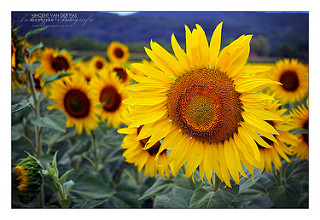

In [42]:
Image.open('C:/Users/storm/.keras/datasets/flower_photos/sunflowers/3749090865_b90f28a585_n.jpg')

In [43]:
print(type(x[0]))
x[0]

<class 'pathlib.WindowsPath'>


WindowsPath('C:/Users/storm/.keras/datasets/flower_photos/daisy/100080576_f52e8ee070_n.jpg')

str 안붙여도 가능
> duck typing
  문자열에서 객체로 넣어도 객체에서 원하는 기능만 있으면 실행  

C:\Users\storm\.keras\datasets\flower_photos\daisy\100080576_f52e8ee070_n.jpg


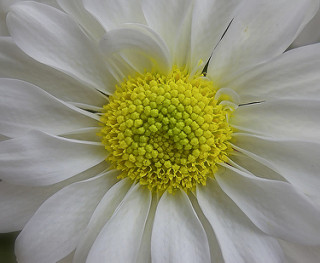

In [44]:
print(str(x[0]))
Image.open(str(x[0]))

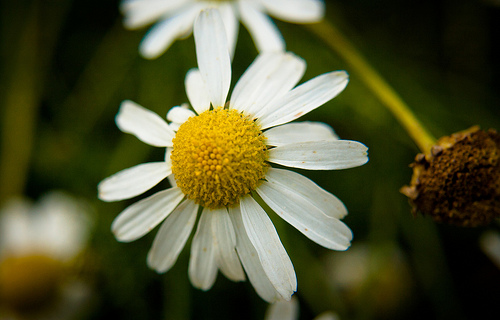

In [45]:
Image.open(x[10])  # str 없어도 가능 <duck typing>  ;  이미지별 size 다름

### keras.preprocessing을 사용하여 로드  
- 기본적인 컨볼루션 사용가능 할까?
- 이미지 크기 상이
  - resize, crop 
  - 데이터가 많으면 각 사진마다 할 수가 없어서 ML 이용해서 크기 맞출 수도 있음 (ML에서는 결측치 처리와 비슷함)
#### image_dataset_from_directory
- directory에서 이미지 데이터 세트를 만듦
    - 기본값 rgb로 256x256크기로 bach 32size

-  image_dataset_from_directory(
    directory,
    labels='inferred',
    label_mode='int',
    class_names=None,
    color_mode='rgb',
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation='bilinear',
    follow_links=False,
    crop_to_aspect_ratio=False,
    **kwargs )

In [46]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [47]:
from keras.preprocessing.image import ImageDataGenerator

In [48]:
from tensorflow.keras.preprocessing import image_dataset_from_directory

In [49]:
from keras.utils import image_dataset_from_directory # directory에서 이미지 데이터 세트를 만듦

In [50]:
data_dir

WindowsPath('C:/Users/storm/.keras/datasets/flower_photos')

In [51]:
train_data = image_dataset_from_directory(data_dir,image_size=(180,180))
train_data
# BatchDataset (None,180,180,3)

Found 3670 files belonging to 5 classes.


<BatchDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [52]:
dir(train_data) # class_names,  __iter__ -> iterable  ,for 사용가능,iterator만들기 가능

['_GeneratorState',
 '__abstractmethods__',
 '__annotations__',
 '__bool__',
 '__class__',
 '__class_getitem__',
 '__debug_string__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__nonzero__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__tf_tracing_type__',
 '__weakref__',
 '_abc_impl',
 '_add_trackable_child',
 '_add_variable_with_custom_getter',
 '_apply_debug_options',
 '_as_serialized_graph',
 '_batch_size',
 '_checkpoint_dependencies',
 '_common_args',
 '_consumers',
 '_convert_variables_to_tensors',
 '_deferred_dependencies',
 '_deserialization_dependencies',
 '_deserialize_from_proto',
 '_drop_remainder',
 '_export_to_saved_model_graph',
 '_flat_shapes',
 '_flat_structure',
 '_flat_types',

In [53]:
train_data.class_names   # dir기반으로 class 이름 자동으로 뽑음

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

In [54]:
x = iter(train_data)

In [55]:
next(x)  # (32, 180, 180, 3), (32,)

(<tf.Tensor: shape=(32, 180, 180, 3), dtype=float32, numpy=
 array([[[[1.87833328e+02, 1.53000000e+02, 1.20500000e+02],
          [1.92500000e+02, 1.47166672e+02, 9.20000000e+01],
          [1.94833328e+02, 1.42666672e+02, 9.23333359e+01],
          ...,
          [8.33333282e+01, 8.05000000e+01, 8.11666641e+01],
          [8.00000000e+01, 7.70000000e+01, 7.58333282e+01],
          [7.66666641e+01, 7.36666641e+01, 7.25000000e+01]],
 
         [[1.81500000e+02, 1.47500000e+02, 1.12500000e+02],
          [1.90500000e+02, 1.44000000e+02, 8.65000000e+01],
          [1.94500000e+02, 1.41500000e+02, 8.85000000e+01],
          ...,
          [8.90000000e+01, 6.95000000e+01, 4.40000000e+01],
          [8.90000000e+01, 6.90000000e+01, 4.30000000e+01],
          [8.90000000e+01, 6.90000000e+01, 4.30000000e+01]],
 
         [[1.82666672e+02, 1.47000000e+02, 1.11166664e+02],
          [1.93500000e+02, 1.47500000e+02, 8.85000000e+01],
          [1.97500000e+02, 1.44500000e+02, 9.05000000e+01],
    

In [56]:
len(next(x))

2

In [57]:
a,b = next(x) # unpacking : X train, Y label 분할

In [58]:
b

<tf.Tensor: shape=(32,), dtype=int32, numpy=
array([3, 4, 4, 0, 2, 1, 2, 1, 4, 4, 1, 3, 1, 2, 1, 1, 1, 3, 1, 3, 1, 2,
       4, 3, 3, 0, 4, 0, 3, 1, 4, 0])>

In [59]:
 # 너무 오래걸리므로 i를 이용해서 1개
for i in train_data: 
    print(i)
    break

(<tf.Tensor: shape=(32, 180, 180, 3), dtype=float32, numpy=
array([[[[1.75388889e+01, 1.99191360e+01, 4.84197521e+00],
         [1.87129631e+01, 2.33314800e+01, 1.42592654e-01],
         [2.00932102e+01, 2.62833328e+01, 0.00000000e+00],
         ...,
         [2.89821205e+01, 2.49358006e+01, 4.10924959e+00],
         [2.33314533e+01, 2.06666870e+01, 2.37953663e+00],
         [1.90136452e+01, 1.90000000e+01, 3.31669378e+00]],

        [[2.19611111e+01, 2.49611111e+01, 5.55370378e+00],
         [2.35166664e+01, 2.88500004e+01, 3.28333330e+00],
         [2.66574078e+01, 3.37833328e+01, 4.40740764e-01],
         ...,
         [3.34203873e+01, 2.72981796e+01, 1.08148050e+01],
         [2.76611061e+01, 2.10944386e+01, 6.42218733e+00],
         [2.22648888e+01, 2.02518597e+01, 5.17224932e+00]],

        [[2.74043198e+01, 3.15432091e+01, 5.84876537e+00],
         [2.85185165e+01, 3.39444427e+01, 6.57407379e+00],
         [3.26604919e+01, 4.07222214e+01, 5.55555820e-01],
         ...,
         

In [60]:
for i ,j in train_data:  #너무 오래걸리므로 i이용해서 1개
    print(i)
    print('-------')
    print(j)
    break

tf.Tensor(
[[[[1.18888893e+01 2.18888893e+01 0.00000000e+00]
   [1.31861115e+01 2.28138885e+01 0.00000000e+00]
   [9.55555534e+00 2.15555553e+01 0.00000000e+00]
   ...
   [0.00000000e+00 2.00000000e+00 0.00000000e+00]
   [0.00000000e+00 2.00006104e+00 0.00000000e+00]
   [0.00000000e+00 0.00000000e+00 0.00000000e+00]]

  [[1.08888893e+01 1.98888893e+01 0.00000000e+00]
   [1.20000000e+01 2.10000000e+01 0.00000000e+00]
   [9.55555534e+00 2.15555553e+01 0.00000000e+00]
   ...
   [0.00000000e+00 2.00000000e+00 0.00000000e+00]
   [3.33312988e-01 1.66668701e+00 0.00000000e+00]
   [8.88916016e-01 8.88916016e-01 0.00000000e+00]]

  [[1.08425932e+01 1.99120369e+01 8.88888836e-01]
   [1.11944447e+01 2.06111126e+01 0.00000000e+00]
   [9.02314854e+00 2.12083340e+01 0.00000000e+00]
   ...
   [0.00000000e+00 1.20833349e+00 0.00000000e+00]
   [0.00000000e+00 1.33337402e+00 0.00000000e+00]
   [8.14809024e-01 8.14809024e-01 0.00000000e+00]]

  ...

  [[0.00000000e+00 4.00000000e+00 0.00000000e+00]
   [0

- PIL로 전체를 보기 힘드므로 
- directory 이용해서 간단하게 모든 데이터를 tensor형태로 바꾸면 편함 

In [61]:
dir(train_data)  # map, filter ,reduce 삼총사

['_GeneratorState',
 '__abstractmethods__',
 '__annotations__',
 '__bool__',
 '__class__',
 '__class_getitem__',
 '__debug_string__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__nonzero__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__tf_tracing_type__',
 '__weakref__',
 '_abc_impl',
 '_add_trackable_child',
 '_add_variable_with_custom_getter',
 '_apply_debug_options',
 '_as_serialized_graph',
 '_batch_size',
 '_checkpoint_dependencies',
 '_common_args',
 '_consumers',
 '_convert_variables_to_tensors',
 '_deferred_dependencies',
 '_deserialization_dependencies',
 '_deserialize_from_proto',
 '_drop_remainder',
 '_export_to_saved_model_graph',
 '_flat_shapes',
 '_flat_structure',
 '_flat_types',

### layers.experimental.preprocessing
- 전처리 레이어 지원:
    - Resizing layer 
    - Rescaling layer
    - CenterCrop layer
- functional API: layer는 함수처럼 쓸 수 있다.
- 나중에 바뀔수 있음
- 참고 : https://keras.io/guides/preprocessing_layers/

In [62]:
tf.keras.layers.experimental.preprocessing # 나중에 바뀔수도 있어서 experimental 에 있음

<module 'keras.api._v2.keras.layers.experimental.preprocessing' from 'c:\\MyCursorLab\\tf210\\.venv\\lib\\site-packages\\keras\\api\\_v2\\keras\\layers\\experimental\\preprocessing\\__init__.py'>

#### Rescaling
- Rescaling 레이어를 사용하여 [0, 1] 범위로 값을 정규화 , 0 ~ 1.0 배율
- 참고 : https://keras.io/guides/preprocessing_layers/ 

 map : 호출하여 데이터 세트에 적용

In [63]:
normalization_layer = tf.keras.layers.experimental.preprocessing.Rescaling(1/255)

In [64]:
a = train_data.map(lambda x,y:(normalization_layer(x),y)) # 함수형 패러다임
a           

<MapDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [65]:
next(iter(a))

(<tf.Tensor: shape=(32, 180, 180, 3), dtype=float32, numpy=
 array([[[[3.47966611e-01, 4.36528742e-01, 2.11111128e-01],
          [4.80283260e-01, 5.15577376e-01, 2.71350771e-01],
          [2.64778495e-01, 4.81445193e-01, 1.70660447e-02],
          ...,
          [4.23128098e-01, 5.20840585e-01, 2.28213355e-01],
          [2.97821164e-01, 3.52613568e-01, 1.75925404e-01],
          [3.35656881e-01, 3.46187025e-01, 1.77378282e-01]],
 
         [[4.39869314e-01, 4.93028343e-01, 5.65686285e-01],
          [3.52614373e-01, 5.59803963e-01, 3.89215678e-01],
          [1.80610031e-01, 3.74727696e-01, 5.18518388e-02],
          ...,
          [2.21677601e-01, 2.69499183e-01, 1.01961389e-01],
          [3.52615982e-01, 3.75818133e-01, 2.87256777e-01],
          [2.96732128e-01, 3.12963098e-01, 2.04248711e-01]],
 
         [[2.66158283e-01, 3.06245476e-01, 1.89687669e-01],
          [3.72549027e-01, 4.66230959e-01, 2.85947710e-01],
          [3.21713351e-02, 6.12199567e-02, 1.38343973e-02],
    

In [66]:
# lambda에 인수가 두개
# f = lambda x,y: (x*10,y)
# x2,y2 = f(10,20)
# x2,y2

#### 데이터 입력 파이프라인 구축
-  tf.data : low level 로 구축하는 방법( 디렉토리/ pandas DataFrame)
    - tf.data API 사용하면 간단하고 재사용 가능한 조각으로 입력 파이프라인 빌드할 수 있음
- 세밀한 제어 가능

In [67]:
type(a)

tensorflow.python.data.ops.dataset_ops.MapDataset

In [68]:
issubclass(type(a),tf.data.Dataset) #지원 받음 -> 학습데이터 구성 가능, 모델 내에 넣어서 연결함 
# https://www.tensorflow.org/jvm/api_docs/java/org/tensorflow/framework/data/impl/MapDataset
# MapDataset은 tf.data.Datase을 상속 받아 구현됨

True

In [69]:
tf.data.Dataset

tensorflow.python.data.ops.dataset_ops.DatasetV2

In [70]:
dir(tf.data.Dataset)

['_GeneratorState',
 '__abstractmethods__',
 '__annotations__',
 '__bool__',
 '__class__',
 '__class_getitem__',
 '__debug_string__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__nonzero__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__tf_tracing_type__',
 '__weakref__',
 '_abc_impl',
 '_add_trackable_child',
 '_add_variable_with_custom_getter',
 '_apply_debug_options',
 '_as_serialized_graph',
 '_checkpoint_dependencies',
 '_common_args',
 '_consumers',
 '_convert_variables_to_tensors',
 '_deferred_dependencies',
 '_deserialization_dependencies',
 '_deserialize_from_proto',
 '_export_to_saved_model_graph',
 '_flat_shapes',
 '_flat_structure',
 '_flat_types',
 '_functions',
 '_gather_saveables_